# Exercise E3

This notebook to produce the following maps

* The Antarctic continent and the Southern Ocean starting from 60°S
* The South Atlantic, from 20°S to 50°S. The map should show the following locations: Walvis Bay, Cape Town, Rio de Janeiro, Montevideo

In [1]:
import cartopy.crs as ccrs
import cartopy
import cartopy.feature as cfeature
import matplotlib.pyplot as plt
import numpy as np
# these modules will be used later
from geopy.geocoders import Nominatim
from geopy.distance import geodesic

## Exercise 1: South Pole

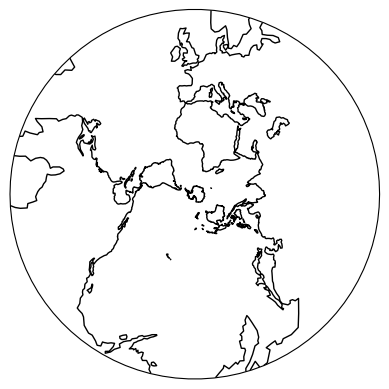

In [3]:
#SouthPolarStereo projection of the South Pole
plt.figure()
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.coastlines()

In [29]:
#South Polar Stereographic projection (best for maps centered on Antarctica). This allows professional and accurate display of the Antarctic continent and the Southern Ocean.
ccrs.SouthPolarStereo?

Init signature:
ccrs.SouthPolarStereo(
    central_longitude=0.0,
    true_scale_latitude=None,
    globe=None,
)
Docstring:     
Define a projected coordinate system with flat topology and Euclidean
distance.
Init docstring:
Parameters
----------
proj4_params: iterable of key-value pairs
    The proj4 parameters required to define the
    desired CRS.  The parameters should not describe
    the desired elliptic model, instead create an
    appropriate Globe instance. The ``proj4_params``
    parameters will override any parameters that the
    Globe defines.
globe: :class:`~cartopy.crs.Globe` instance, optional
    If omitted, the default Globe instance will be created.
    See :class:`~cartopy.crs.Globe` for details.
File:           c:\users\yibanathima\appdata\local\anaconda3\envs\samos-core3\lib\site-packages\cartopy\crs.py
Type:           ABCMeta
Subclasses:     

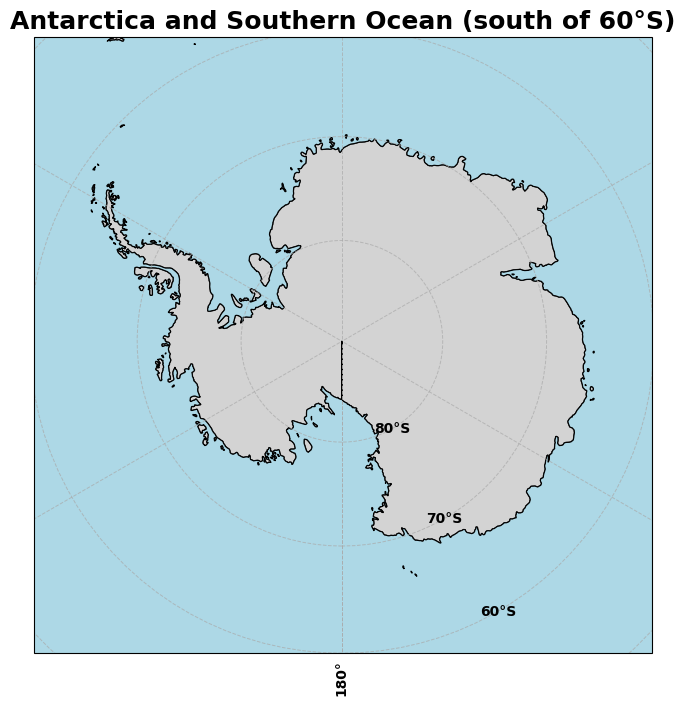

In [34]:
# Define extent: Antarctica and Southern Ocean south of 60°S
extent = [-180, 180, -90, -60]

plt.figure(figsize=(8, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add base features
ax.add_feature(cfeature.LAND, facecolor='lightgrey', edgecolor='black')
ax.add_feature(cfeature.OCEAN, facecolor='lightblue')
ax.add_feature(cfeature.COASTLINE, linewidth=0.8)
ax.add_feature(cfeature.BORDERS, linestyle=':', linewidth=0.5)

# Gridlines with labels
gl = ax.gridlines(draw_labels=True,
                  linewidth=0.7,
                  color='darkgrey',
                  alpha=0.7,
                  linestyle='--')

# Show labels only on bottom and left
gl.top_labels = False
gl.right_labels = False
gl.bottom_labels = True
gl.left_labels = True

gl.xlabel_style = {'size': 10, 'color': 'black', 'weight': 'bold'}
gl.ylabel_style = {'size': 10, 'color': 'black', 'weight': 'bold'}

# Title of the map
plt.title("Antarctica and Southern Ocean (south of 60°S)",
          fontsize=18, weight='bold')

#Plot and show the map using matplotlib
plt.show()


## Exercise 2

In [4]:
#
geolocator = Nominatim(user_agent='educational') # nominatim is a free service and requires an identificative agent
CT = geolocator.geocode('Cape Town') 
SANAE = geolocator.geocode('SANAE IV')
print(type(CT))
print(CT,CT.point)
print(SANAE,SANAE.point)
print('The distance is ',geodesic(CT.point,SANAE.point).km,' km')

<class 'geopy.location.Location'>
Cape Town, City of Cape Town, Western Cape, 8001, South Africa 33 55m 43.7884s S, 18 25m 1.99092s E
SANAE IV 71 40m 25.2163s S, 2 49m 43.7081s W
The distance is  4382.159276626553  km


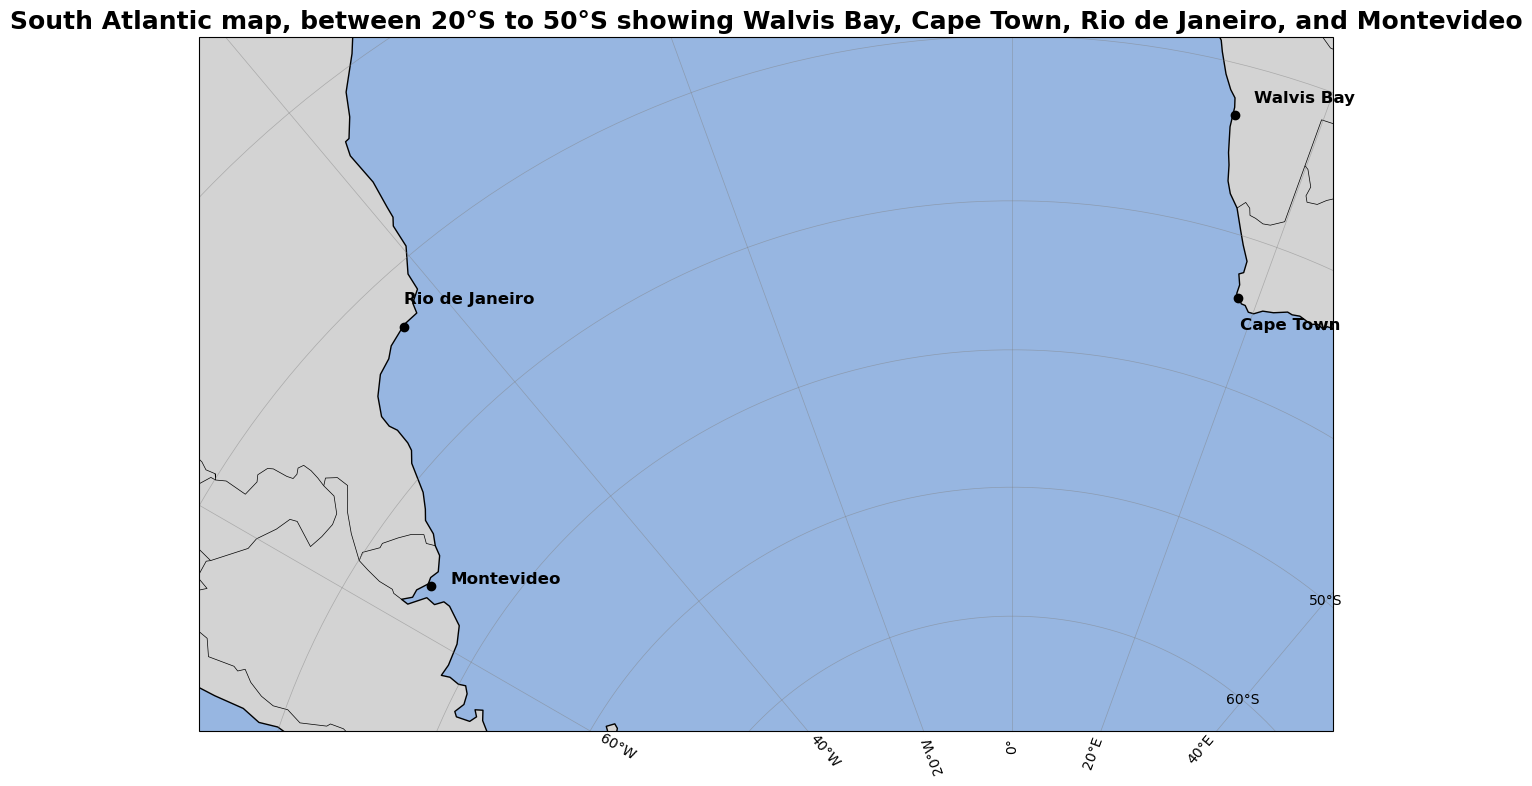

In [35]:
# Define extent: [min_lon, max_lon, min_lat, max_lat]
extent = [-60, 20, -50, -20]  # South Atlantic 
central_lon = np.mean(extent[:2])
central_lat = np.mean(extent[2:])

# Geolocate regions
geolocator = Nominatim(user_agent="city_locator")
place = ['Walvis Bay', 'Cape Town', 'Rio de Janeiro', 'Montevideo']
coords = []
for p in place:
    loc = geolocator.geocode(p, language="en")
    coords.append((p, loc.longitude, loc.latitude))

# Create figures
plt.figure(figsize=(12, 8))
ax = plt.axes(projection=ccrs.SouthPolarStereo())
ax.set_extent(extent, crs=ccrs.PlateCarree())

# Add base features
ax.add_feature(cfeature.OCEAN)
ax.add_feature(cfeature.LAND, facecolor='lightgrey')
ax.add_feature(cfeature.LAKES, facecolor='lightblue')
ax.add_feature(cfeature.BORDERS, linewidth=0.5)
ax.coastlines(resolution='110m')

#Adding gridlines
gl = ax.gridlines(draw_labels=True,
                  linestyle='-',
                  linewidth=0.5,
                  color='gray',
                  alpha=0.5)

# Show labels only on bottom and left
gl.top_labels = False
gl.right_labels = False

# Plot cities with smarter spacing
for name, lon, lat in coords:
    ax.plot(lon, lat, 'o', color='black', markersize=6, transform=ccrs.PlateCarree())

# Adjust offsets per region
    if "Cape Town" in name:
        offset = (1, -2)
    elif "Walvis Bay" in name:
        offset = (1, 1)
    elif "Rio" in name:
        offset = (1, 1)
    else:  # Montevideo
        offset = (1, -1)

    ax.text(lon + offset[0], lat + offset[1],
            name,
            fontsize=12,
            fontweight='bold',
            fontfamily='DejaVu Sans',
            transform=ccrs.PlateCarree())

# Title of the map
plt.title("South Atlantic map, between 20°S to 50°S showing Walvis Bay, Cape Town, Rio de Janeiro, and Montevideo",
          fontsize=18,
          weight='bold')

#Plot and show map using matplotlib.pyplot
plt.tight_layout()
plt.show()

